# Ajou ECG Fine-tuning & Denoising (Lead II @ 267 Hz)
## R-Peak Detection Based Evaluation (No Pseudo-Labels)

## 데이터 개요 (Data Overview)

- 데이터 종류: 6-Lead 심전도(ECG) + 온도
- 파일 형식: 탭(tab) 구분 텍스트 파일 (.txt)
- 측정 항목: Lead I, Lead II, Lead III, aVR, aVL, aVF, Temperature
- 샘플링 속도: 267 Hz (초당 267 샘플)
- **Annotation: None** (R-peak 검출로 성능 평가)

## 개선된 파이프라인

1) Lead II 선택 → 267 Hz → 360 Hz로 리샘플링(모델 호환)
2) **의사 정답 제거**: 디노이징 품질을 R-peak 검출 성능으로 평가
3) 512 샘플 창, 256 hop 으로 프레이밍 + Fourier 특성 구성
4) 사전학습된 Dual_FreqDAE 가중치 로드 → Ajou 데이터로 미세조정(Fine-tune)
5) 예측 프레임을 Overlap-Add 로 복원
6) **R-peak 검출** (Pan-Tompkins)로 Raw vs Denoised 비교
7) **평가 지표**: F1, Precision, Recall, FP 감소율
8) 시각화: Raw vs Denoised 오버레이 + R-peak 마킹

In [111]:
# === 1. Import Libraries ===
import numpy as np
import pandas as pd
import os
import json
from math import gcd

# Signal processing
import scipy.signal as signal
from scipy.signal import resample_poly, find_peaks, welch, filtfilt

# Deep learning
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

# Visualization
import matplotlib.pyplot as plt
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Project modules
from Data_Preparation.data_preparation_with_fourier import make_fourier
from digitalFilters.dfilters import IIRRemoveBL, IIRRemoveHF
from deepFilter.dl_models import Dual_FreqDAE
from deepFilter.dl_pipeline import combined_ssd_mad_loss

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


In [112]:
# === 2. Configuration ===
fs_src = 267      # Original sampling rate (Hz)
fs_tgt = 360      # Target sampling rate for model (Hz)
WIN = 512         # Window size
HOP = 256         # Hop size (50% overlap)

# Paths
ajou_dir = "ajou_data"
output_dir = "ajou_outputs"
ft_dir = "ajou_finetune"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(ft_dir, exist_ok=True)

# Pretrained weights
pretrained_path = "/home/dhc99/ecg_denoise/0221_FIXED/Dual_FreqDAE_weights.best.weights.h5"

print(f"✓ Configuration set: fs_src={fs_src}Hz, fs_tgt={fs_tgt}Hz, WIN={WIN}, HOP={HOP}")

✓ Configuration set: fs_src=267Hz, fs_tgt=360Hz, WIN=512, HOP=256


In [113]:
# === 3. Load Ajou ECG Data (Lead II @ 267 Hz) ===

# Discover all sgTest_*.txt files
cand = sorted([p for p in os.listdir(ajou_dir) if p.startswith("sgTest_") and p.endswith(".txt")])
if not cand:
    raise FileNotFoundError("No sgTest_*.txt found under ajou_data/")

print("Discovered files (sorted):")
for fname in cand:
    print(f"  - {fname}")
# 각 파일은 탭(\t)으로 구분된 텍스트 파일입니다
# 열 구조: Lead I, Lead II, Lead III, aVR, aVL, aVF, Temperature
# **열 인덱스 1 (두 번째 컬럼)**이 Lead II입니다
lead2_raw_segments = []
segment_meta = []
for fname in cand:
    path = os.path.join(ajou_dir, fname)
    df = pd.read_csv(path, sep="\t", header=None)  # Lead columns + temperature
    trace = df.iloc[:, 1].astype(float).to_numpy()  # Column 1 = Lead II
    lead2_raw_segments.append(trace)
    segment_meta.append({
        "file": fname,
        "samples": trace.shape[0],
        "duration_s": trace.shape[0] / fs_src,
        "min": float(trace.min()),
        "max": float(trace.max()),
    })

lead2_raw = np.concatenate(lead2_raw_segments)
segment_lengths_raw = [meta["samples"] for meta in segment_meta]
segment_offsets_raw = np.cumsum(segment_lengths_raw)

total_duration = len(lead2_raw) / fs_src
print(f"\nAggregated Lead II signals: {len(cand)} files")
print(f"  Total samples: {len(lead2_raw)}")
print(f"  Total duration: {total_duration:.2f} seconds ({total_duration/60:.2f} minutes)")
print(f"  Sample range across all files: [{lead2_raw.min():.3f}, {lead2_raw.max():.3f}]")

print("\nPer-file summary:")
for meta in segment_meta:
    print(
        f"  {meta['file']}: {meta['samples']} samples "
        f"({meta['duration_s']:.2f} s), range [{meta['min']:.3f}, {meta['max']:.3f}]"
    )

Discovered files (sorted):
  - sgTest_20251029_042816.txt
  - sgTest_20251031_030539.txt
  - sgTest_20251031_030658.txt
  - sgTest_20251031_030819.txt

Aggregated Lead II signals: 4 files
  Total samples: 217820
  Total duration: 815.81 seconds (13.60 minutes)
  Sample range across all files: [-465992.400, 746412.100]

Per-file summary:
  sgTest_20251029_042816.txt: 157860 samples (591.24 s), range [-437226.100, 211455.700]
  sgTest_20251031_030539.txt: 20360 samples (76.25 s), range [-465992.400, 746412.100]
  sgTest_20251031_030658.txt: 20180 samples (75.58 s), range [-122387.100, 132079.300]
  sgTest_20251031_030819.txt: 19420 samples (72.73 s), range [-134072.800, 134524.200]

Aggregated Lead II signals: 4 files
  Total samples: 217820
  Total duration: 815.81 seconds (13.60 minutes)
  Sample range across all files: [-465992.400, 746412.100]

Per-file summary:
  sgTest_20251029_042816.txt: 157860 samples (591.24 s), range [-437226.100, 211455.700]
  sgTest_20251031_030539.txt: 2036

In [114]:
# === 4. Resample 267 Hz → 360 Hz ===

_g = gcd(fs_tgt, fs_src)
up, down = fs_tgt // _g, fs_src // _g

lead2_360_segments = []
segment_lengths_360 = []
for idx, trace in enumerate(lead2_raw_segments):
    resampled = resample_poly(trace, up, down)
    lead2_360_segments.append(resampled)
    segment_lengths_360.append(len(resampled))

lead2_360 = np.concatenate(lead2_360_segments)
segment_offsets_360 = np.cumsum(segment_lengths_360)
compression_ratio = len(lead2_360) / len(lead2_raw)

print("Resampling summary:")
for meta, resampled in zip(segment_meta, lead2_360_segments):
    ratio = len(resampled) / meta["samples"]
    print(
        f"  {meta['file']}: {meta['samples']} samples → {len(resampled)} samples "
        f"(ratio {ratio:.4f})"
    )

print(f"\nAggregated resampled signal:")
print(f"  Total samples: {len(lead2_raw)} @ {fs_src}Hz → {len(lead2_360)} @ {fs_tgt}Hz")
print(f"  Overall compression ratio: {compression_ratio:.4f}")

Resampling summary:
  sgTest_20251029_042816.txt: 157860 samples → 212845 samples (ratio 1.3483)
  sgTest_20251031_030539.txt: 20360 samples → 27452 samples (ratio 1.3483)
  sgTest_20251031_030658.txt: 20180 samples → 27209 samples (ratio 1.3483)
  sgTest_20251031_030819.txt: 19420 samples → 26185 samples (ratio 1.3484)

Aggregated resampled signal:
  Total samples: 217820 @ 267Hz → 293691 @ 360Hz
  Overall compression ratio: 1.3483


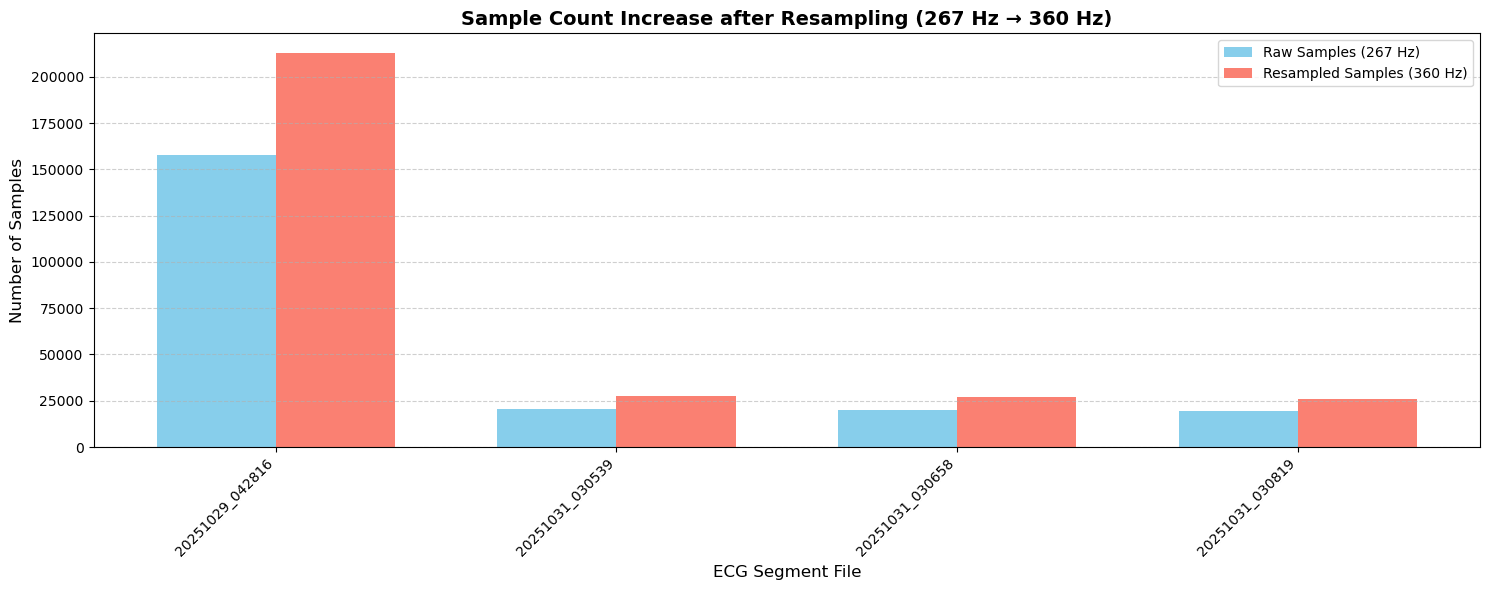

In [115]:
# === 4.5. 리샘플링 샘플 수 증가 시각화 ===

file_names = [meta['file'] for meta in segment_meta]
samples_raw = [meta['samples'] for meta in segment_meta]
samples_360 = segment_lengths_360 # Resampling 후 샘플 수 (list)

# 파일 이름을 x축 레이블로 사용 (너무 길면 줄임)
x_labels = [name.replace("sgTest_", "").replace(".txt", "") for name in file_names]
x = np.arange(len(x_labels))  # x축 위치

plt.figure(figsize=(15, 6))
width = 0.35  # 막대 폭

# 원본 샘플 수 막대
rects1 = plt.bar(x - width/2, samples_raw, width, label=f'Raw Samples ({fs_src} Hz)', color='skyblue')
# 리샘플링 후 샘플 수 막대
rects2 = plt.bar(x + width/2, samples_360, width, label=f'Resampled Samples ({fs_tgt} Hz)', color='salmon')

# 그래프 제목 및 레이블 설정
plt.xlabel('ECG Segment File', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title(f'Sample Count Increase after Resampling ({fs_src} Hz → {fs_tgt} Hz)', fontweight='bold', fontsize=14)
plt.xticks(x, x_labels, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# y축 레이블을 정수로 포맷팅
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        # 샘플 수 위에 텍스트로 표시
        plt.annotate(f'{height:,}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=8, rotation=90)

# autolabel(rects1)
# autolabel(rects2)

plt.tight_layout()
plt.show()

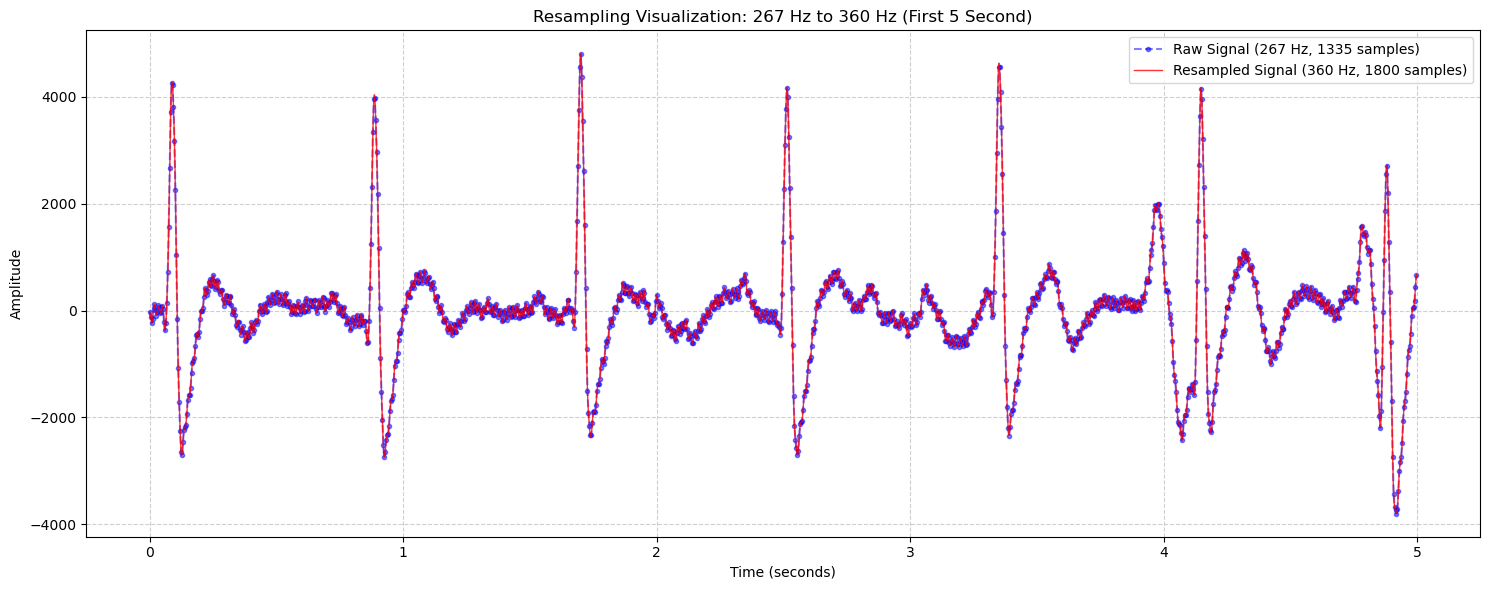

In [135]:
# === 5. Resampling Visualization ===

# 첫 번째 세그먼트의 Raw 및 Resampled 데이터 추출
# Raw: 267 Hz
raw_segment = lead2_raw_segments[0]
# Resampled: 360 Hz
resampled_segment = lead2_360_segments[0]

# 비교를 위해 신호의 시작 부분만 추출 (예: 1초, 즉 267 샘플)
# 1초 길이 (267Hz 기준): 267 샘플
# 1초 길이 (360Hz 기준): 360 샘플
comparison_duration_s = 5
raw_samples_to_show = int(fs_src * comparison_duration_s) # 267
resampled_samples_to_show = int(fs_tgt * comparison_duration_s) # 360

raw_slice = raw_segment[:raw_samples_to_show]
resampled_slice = resampled_segment[:resampled_samples_to_show]

# 시간 축 생성 (두 신호 모두 0초부터 1초까지)
time_raw = np.linspace(0, comparison_duration_s, len(raw_slice), endpoint=False)
time_resampled = np.linspace(0, comparison_duration_s, len(resampled_slice), endpoint=False)


plt.figure(figsize=(15, 6))

# 267 Hz 신호 (점선 및 마커로 샘플 위치 강조)
plt.plot(time_raw, raw_slice, 'o--', color='blue', alpha=0.5, label=f'Raw Signal ({fs_src} Hz, {len(raw_slice)} samples)', markersize=3)
# 360 Hz 신호 (실선으로 부드러운 보간 강조)
plt.plot(time_resampled, resampled_slice, '-', color='red', alpha=0.8, label=f'Resampled Signal ({fs_tgt} Hz, {len(resampled_slice)} samples)', linewidth=1)

plt.title(f'Resampling Visualization: {fs_src} Hz to {fs_tgt} Hz (First {comparison_duration_s} Second)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [117]:
# # === 5. Frame Signal & Build Model Inputs ===

# def frame_signal(x, win=512, hop=256, pad_mode="reflect"):
#     """Frame signal with overlap and padding."""
#     x = np.asarray(x, dtype=float)
#     n = len(x)
    
#     if n < win:
#         pad = win - n
#         x = np.pad(x, (0, pad), mode=pad_mode)
    
#     n = len(x)
#     n_frames = 1 + (n - win + hop - 1) // hop
#     total_needed = (n_frames - 1) * hop + win
    
#     if total_needed > n:
#         extra = total_needed - n
#         x = np.pad(x, (0, extra), mode=pad_mode)
    
#     frames = [x[i*hop:i*hop+win] for i in range(n_frames)]
#     return np.stack(frames, axis=0), len(x)

# # Frame the signal
# X2d, padded_len = frame_signal(lead2_360, WIN, HOP)
# X_train = np.expand_dims(X2d, axis=2)  # Shape: (N, 512, 1)

# # Frequency domain (Fourier features)
# F_train_x = make_fourier(X2d, n=WIN, fs=fs_tgt)
# F_train_x = np.expand_dims(F_train_x, axis=2)  # Shape: (N, 512, 1)

# print(f"✓ Framing complete:")
# print(f"  Time domain: {X_train.shape}")
# print(f"  Frequency domain: {F_train_x.shape}")
# print(f"  Padded length: {padded_len}")

# === 4c. Noise Removal Digital Filtering (New Step for R-peak Stability) ===
print("\n" + "="*70)
print("NOISE REMOVAL DIGITAL FILTERING (Pre-processing for Stability)")
print("="*70)

# 1. Baseline Wander (저주파 노이즈, < 0.67 Hz) 제거
# IIRRemoveBL 함수를 사용하여 기선 변동 제거
try:
    # 차단 주파수 Fc=0.67 Hz 명시적으로 전달
    lead2_360_filtered = IIRRemoveBL(lead2_360, fs_tgt, 0.67) 
    print("✓ Low-frequency Baseline Wander removed (< 0.67 Hz).")
except NameError:
    # IIRRemoveBL이 정의되지 않은 경우를 대비한 대체 필터링 (e.g., 0.5 Hz highpass)
    nyquist = 0.5 * fs_tgt
    cutoff_freq = 0.5 / nyquist
    b_bl, a_bl = signal.butter(4, cutoff_freq, 'highpass', analog=False)
    lead2_360_filtered = signal.filtfilt(b_bl, a_bl, lead2_360)
    print("✓ Low-frequency Baseline Wander removed using 0.5Hz highpass filter.")
    
# 2. High Frequency Noise (> 150 Hz) 제거 (선택적)
# IIRRemoveHF 함수를 사용하여 고주파 노이즈 제거
try:
    # 차단 주파수 Fc=150.0 Hz 명시적으로 전달
    lead2_360_filtered = IIRRemoveHF(lead2_360_filtered, fs_tgt, 150.0) 
    print("✓ High-frequency noise removed (> 150 Hz).")
except NameError:
    # IIRRemoveHF가 정의되지 않은 경우를 대비한 대체 필터링 (e.g., 150 Hz lowpass)
    nyquist = 0.5 * fs_tgt
    cutoff_freq = 150.0 / nyquist
    b_hf, a_hf = signal.butter(4, cutoff_freq, 'lowpass', analog=False)
    lead2_360_filtered = signal.filtfilt(b_hf, a_hf, lead2_360_filtered)
    print("✓ High-frequency noise removed using 150Hz lowpass filter.")

# 필터링된 신호를 lead2_360 변수에 다시 할당
lead2_360 = lead2_360_filtered


# === 5. Frame Signal & Build Model Inputs (Reverting to Overlap Framing) ===
# 이전의 R-peak 기반 분할 로직 대신, 원래의 오버랩 프레이밍 로직으로 복귀합니다.

def frame_signal(x, win=512, hop=256, pad_mode="reflect"):
    """Frame signal with overlap and padding."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    
    # 길이가 윈도우보다 짧을 경우 패딩
    if n < win:
        pad = win - n
        x = np.pad(x, (0, pad), mode=pad_mode)
    
    n = len(x)
    # 필요한 프레임 개수 계산
    n_frames = 1 + (n - win + hop - 1) // hop
    total_needed = (n_frames - 1) * hop + win
    
    # 마지막 프레임을 위해 필요한 추가 패딩
    if total_needed > n:
        extra = total_needed - n
        x = np.pad(x, (0, extra), mode=pad_mode)
    
    frames = [x[i*hop:i*hop+win] for i in range(n_frames)]
    return np.stack(frames, axis=0), len(x)

# Frame the signal (필터링된 lead2_360 사용)
X2d, padded_len = frame_signal(lead2_360, WIN, HOP)
X_train = np.expand_dims(X2d, axis=2)  # Shape: (N, 512, 1)

# Frequency domain (Fourier features)
# make_fourier는 X2d가 (N, 512) 형태를 기대하므로 X2d를 사용합니다.
F_train_x = make_fourier(X2d, n=WIN, fs=fs_tgt) 
F_train_x = np.expand_dims(F_train_x, axis=2)  # Shape: (N, 512, 1)

print(f"✓ Framing complete (Reverted to Overlap):")
print(f"  Time domain: {X_train.shape}")
print(f"  Frequency domain: {F_train_x.shape}")
print(f"  Padded length: {padded_len}")


NOISE REMOVAL DIGITAL FILTERING (Pre-processing for Stability)
✓ Low-frequency Baseline Wander removed (< 0.67 Hz).
✓ High-frequency noise removed (> 150 Hz).
✓ Framing complete (Reverted to Overlap):
  Time domain: (1147, 512, 1)
  Frequency domain: (1147, 512, 1)
  Padded length: 293888


In [118]:
# === 4b. Baseline Centering (Align with QTDB Training Pipeline) ===
# ECG 신호에서 **DC 오프셋(DC offset)**과 **선형 드리프트(linear drift)**를 제거하여 신호를 0을 중심으로 정렬합니다.

def baseline_centering_segments(signal_360, segment_offsets_360, window_size=512):
    """
    Apply baseline centering to each segment matching QTDB preprocessing.
    
    QTDB preprocessing: b_sq - (b_sq[0] + b_sq[-1]) / 2
    
    However, for long continuous signals, we apply per-window baseline removal
    to match the framing structure (512 samples per frame).
    
    Args:
        signal_360: concatenated signal @ 360Hz
        segment_offsets_360: cumulative lengths of segments
        window_size: size of processing window (should match WIN)
    
    Returns:
        baseline-centered signal
    """
    signal_centered = signal_360.copy()
    
    # Apply baseline centering per segment
    start_idx = 0
    for end_idx in segment_offsets_360:
        segment = signal_centered[start_idx:end_idx]
        
        # Match QTDB preprocessing: subtract mean of first and last sample
        # This removes DC offset and linear drift
        baseline_offset = (segment[0] + segment[-1]) / 2
        signal_centered[start_idx:end_idx] = segment - baseline_offset
        
        print(f"  Segment [{start_idx}:{end_idx}]: baseline_offset = {baseline_offset:.4f}")
        start_idx = end_idx
    
    return signal_centered

print("\n" + "="*70)
print("BASELINE CENTERING (Matching QTDB Preprocessing)")
print("="*70)
print("QTDB 학습 데이터와 동일한 전처리를 적용합니다:")
print("  b_sq - (b_sq[0] + b_sq[-1]) / 2")
print("  → DC offset 및 선형 drift 제거\n")

# Apply baseline centering
lead2_360_original = lead2_360.copy()  # Backup for comparison
lead2_360 = baseline_centering_segments(lead2_360, segment_offsets_360, window_size=WIN)

print(f"\n✓ Baseline centering complete:")
print(f"  Before: mean={lead2_360_original.mean():.6f}, std={lead2_360_original.std():.6f}")
print(f"  After:  mean={lead2_360.mean():.6f}, std={lead2_360.std():.6f}")
print(f"  Signal range: [{lead2_360.min():.6f}, {lead2_360.max():.6f}]")


BASELINE CENTERING (Matching QTDB Preprocessing)
QTDB 학습 데이터와 동일한 전처리를 적용합니다:
  b_sq - (b_sq[0] + b_sq[-1]) / 2
  → DC offset 및 선형 drift 제거

  Segment [0:212845]: baseline_offset = -48.4997
  Segment [212845:240297]: baseline_offset = -2724.4783
  Segment [240297:267506]: baseline_offset = -303.5548
  Segment [267506:293691]: baseline_offset = -845.7116

✓ Baseline centering complete:
  Before: mean=0.073362, std=13257.174097
  After:  mean=393.410818, std=13280.182770
  Signal range: [-460237.774874, 751013.824165]


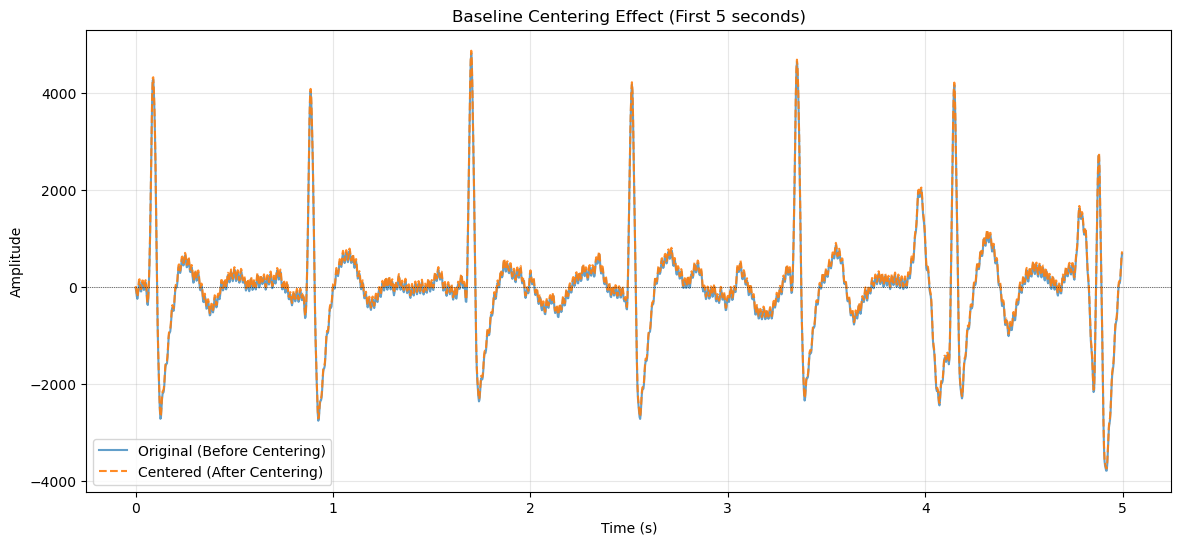

In [119]:
# === 5b. Baseline Centering Visualization ===

# 첫 번째 세그먼트의 길이 (360 Hz 기준)를 사용하여 데이터 추출
first_segment_len = segment_lengths_360[0]
first_segment_duration_s = first_segment_len / fs_tgt

# 비교를 위한 시간 축 생성
time_axis = np.linspace(0, first_segment_duration_s, first_segment_len, endpoint=False)

# 원본 및 중앙화된 첫 번째 세그먼트 추출
# (lead2_360_original은 코드에서 백업된 변수입니다)
segment_original = lead2_360_original[:first_segment_len]
segment_centered = lead2_360[:first_segment_len]

# 신호의 시작 부분만 (예: 처음 5초) 비교하여 DC 오프셋 변화를 명확히 관찰
seconds_to_show = 5
samples_to_show = int(fs_tgt * seconds_to_show)
if samples_to_show > first_segment_len:
    samples_to_show = first_segment_len # 세그먼트가 5초보다 짧으면 전체 표시

# Plotly를 사용하여 상호작용 가능한 차트 생성 (선택 사항)
fig = make_subplots(rows=2, cols=1, 
                    shared_xaxes=True,
                    vertical_spacing=0.1,
                    subplot_titles=(f"Original Signal ({seconds_to_show}s)", 
                                    f"Baseline Centered Signal ({seconds_to_show}s)"))

# 1. 원본 신호 (Original Signal)
fig.add_trace(go.Scatter(y=segment_original[:samples_to_show], 
                         x=time_axis[:samples_to_show], 
                         mode='lines', 
                         name='Original', 
                         line=dict(color='blue')), 
              row=1, col=1)
fig.add_trace(go.Scatter(y=[0]*samples_to_show, 
                         x=time_axis[:samples_to_show], 
                         mode='lines', 
                         name='Zero Line', 
                         line=dict(color='gray', dash='dash')), 
              row=1, col=1)

# 2. 베이스라인 중앙화된 신호 (Centered Signal)
fig.add_trace(go.Scatter(y=segment_centered[:samples_to_show], 
                         x=time_axis[:samples_to_show], 
                         mode='lines', 
                         name='Centered', 
                         line=dict(color='red')), 
              row=2, col=1)
fig.add_trace(go.Scatter(y=[0]*samples_to_show, 
                         x=time_axis[:samples_to_show], 
                         mode='lines', 
                         name='Zero Line', 
                         line=dict(color='gray', dash='dash')), 
              row=2, col=1)

fig.update_layout(height=600, width=900, 
                  title_text=f"Baseline Centering Effect (First Segment @ {fs_tgt} Hz)", 
                  showlegend=False)
fig.update_xaxes(title_text="Time (seconds)", row=2, col=1)
fig.update_yaxes(title_text="Amplitude", row=1, col=1)
fig.update_yaxes(title_text="Amplitude", row=2, col=1)

fig.show()

# Matplotlib으로 단순 비교 시각화 (Jupyter 환경이 아닐 경우)
plt.figure(figsize=(14, 6))
plt.plot(time_axis[:samples_to_show], segment_original[:samples_to_show], label='Original (Before Centering)', alpha=0.7)
plt.plot(time_axis[:samples_to_show], segment_centered[:samples_to_show], label='Centered (After Centering)', alpha=0.9, linestyle='--')
plt.axhline(0, color='black', linestyle=':', linewidth=0.5)
plt.title(f'Baseline Centering Effect (First {seconds_to_show} seconds)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

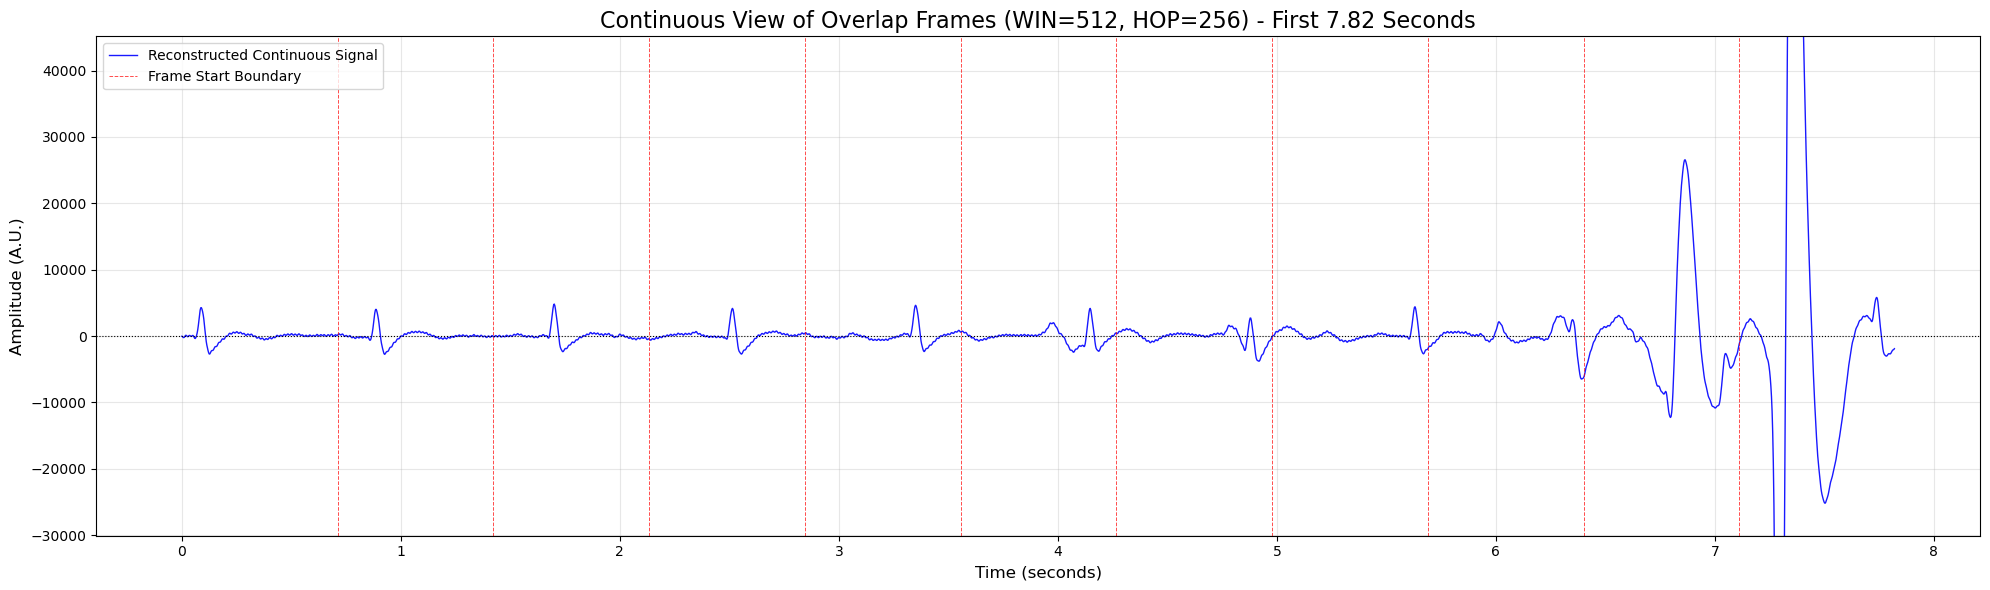

In [120]:
import numpy as np
import matplotlib.pyplot as plt

# --- 사용자 환경 변수 (이전 단계에서 정의됨) ---
# X_train: 오버랩 프레이밍 완료된 데이터 (N, 512, 1)
# fs_tgt: 360 (Hz)
WIN = 512
HOP = 256
# -----------------------------------------------

def visualize_continuous_overlap_frames(X_train, fs_tgt, win_size=WIN, hop_size=HOP, num_frames_to_plot=10):
    """
    오버랩된 프레임(X_train)을 HOP 사이즈(256)를 고려하여 연속적인 시계열로 재구성하고,
    프레임 경계를 표시합니다.
    """
    if X_train.size == 0 or X_train.ndim != 3:
        print("\n⚠️ WARNING: X_train 데이터가 비어 있거나 형태가 올바르지 않습니다.")
        return

    # 시각화할 프레임 개수 제한
    N = min(X_train.shape[0], num_frames_to_plot)
    
    # --- 1. 연속 신호 재구성 (Overlap Reconstruction) ---
    continuous_signal = []
    
    # 각 프레임은 HOP 사이즈만큼만 다음 프레임에 이어 붙여 오버랩을 제거합니다.
    for i in range(N):
        current_frame = X_train[i].squeeze()
        
        if i == 0:
            # 첫 번째 프레임은 전체 WIN(512) 사용
            continuous_signal.extend(current_frame.tolist())
        else:
            # 이후 프레임은 HOP(256)만큼만 (새로운 데이터 부분) 이어 붙입니다.
            # 즉, WIN(512) - HOP(256) = 256 샘플만 추가
            new_data_slice = current_frame[win_size - hop_size:] 
            continuous_signal.extend(new_data_slice.tolist())

    continuous_signal = np.array(continuous_signal)
    total_samples = len(continuous_signal)
    
    # 시간 축 생성
    time_sec = np.linspace(0, (total_samples - 1) / fs_tgt, total_samples)
    
    # y축 범위 계산 (백분위수 기반으로 극단값 제외)
    y_min, y_max = np.percentile(continuous_signal, [1, 99])
    y_margin = (y_max - y_min) * 0.1
    y_limits = [y_min - y_margin, y_max + y_margin]
    
    # --- 2. 시각화 (Frame Markers 포함) ---
    plt.figure(figsize=(20, 6))

    # A. 연속 신호 플롯
    plt.plot(time_sec, continuous_signal, 'b-', linewidth=1.0, alpha=0.9, label='Reconstructed Continuous Signal')

    # B. 프레임 경계선 추가 (HOP 사이즈마다 점선, 새로운 프레임의 시작점)
    frame_boundaries_samples = np.arange(0, total_samples, hop_size)
    for boundary_sample in frame_boundaries_samples:
        # 0번째 경계는 건너뜁니다.
        if boundary_sample == 0:
            continue
            
        boundary_time = boundary_sample / fs_tgt
        # 프레임이 시작되는 지점에 점선 표시
        plt.axvline(x=boundary_time, color='r', linestyle='--', linewidth=0.7, alpha=0.7, label='Frame Start Boundary' if boundary_sample == hop_size else None)

    # C. 베이스라인 (0) 표시
    plt.axhline(0, color='black', linestyle=':', linewidth=0.8)

    # 제목 및 라벨
    duration_s = total_samples / fs_tgt
    plt.title(f'Continuous View of Overlap Frames (WIN={win_size}, HOP={hop_size}) - First {duration_s:.2f} Seconds', fontsize=16)
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Amplitude (A.U.)', fontsize=12)
    plt.ylim(y_limits)  # y축 범위 설정
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# X_train이 생성되었다면, 이 함수를 호출하여 검증할 수 있습니다.
visualize_continuous_overlap_frames(X_train, fs_tgt, num_frames_to_plot=10)

In [121]:
# === GPU 메모리 초기화 ===
import gc
import tensorflow as tf

# 1. 기존 세션 정리
tf.keras.backend.clear_session()

# 2. 가비지 컬렉터 실행
gc.collect()

# 3. GPU 메모리 증가 허용 (동적 메모리 할당)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU 메모리 동적 할당 활성화: {len(gpus)}개 GPU 감지")
    except RuntimeError as e:
        print(f"⚠ GPU 설정 오류: {e}")
else:
    print("⚠ GPU를 찾을 수 없습니다. CPU 모드로 실행됩니다.")

# 4. 현재 GPU 메모리 상태 확인
print("\n현재 GPU 메모리 상태:")
print(tf.config.experimental.get_memory_info('GPU:0') if gpus else "GPU 없음")


✓ GPU 메모리 동적 할당 활성화: 2개 GPU 감지

현재 GPU 메모리 상태:
{'current': 209068032, 'peak': 1761103360}


In [122]:
# === 6. Build & Load Dual_FreqDAE Model ===

model = Dual_FreqDAE(signal_size=WIN)
model.compile(
    loss=combined_ssd_mad_loss,
    optimizer=Adam(learning_rate=1e-4)
)

# Load pretrained weights
if os.path.exists(pretrained_path):
    model.load_weights(pretrained_path)
    print(f"✓ Loaded pretrained weights from {pretrained_path}")
else:
    print(f"⚠ Pretrained weights not found at {pretrained_path}")

print(f"\nModel summary:")
model.summary()

/home/dhc99/anaconda3/envs/ECGDENOISE/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



✓ Loaded pretrained weights from /home/dhc99/ecg_denoise/0221_FIXED/Dual_FreqDAE_weights.best.weights.h5

Model summary:


/home/dhc99/anaconda3/envs/ECGDENOISE/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 418 variables. 



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 256, 16)   │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_gated_noise     │ (None, 256, 16)   │          0 │ conv1d[0][0]      │
│ (AddGatedNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 16)   │          0 │ add_gated_noise[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 256, 16)   │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 256, 16)   │          0 │ activation[0][0], │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 512, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 16)   │         64 │ multiply[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 256, 16)   │        224 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 32)   │      6,688 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 16)   │          0 │ conv1d_6[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 256, 16)   │        224 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_gated_noise_1   │ (None, 128, 32)   │          0 │ conv1d_2[0][0]    │
│ (AddGatedNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 256, 16)   │          0 │ activation_3[0][… │
│ (Multiply)          │                   │            │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 32)   │          0 │ add_gated_noise_… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 32)   │      6,688 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 16)   │         64 │ multiply_3[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 128, 32)   │          0 │ activation_1[0][… │
│ (Multiply)          │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 128, 32)   │      6,688 │ batch_normalizat

 Total params: 3,180,417 (12.13 MB)

 Trainable params: 3,179,873 (12.13 MB)

 Non-trainable params: 544 (2.12 KB)

In [123]:
# === 7. Fine-tune on Ajou Data (Light Training to Avoid Overfitting) ===

print("Starting fine-tuning on Ajou ECG data...")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

hist = model.fit(
    x=[X_train, F_train_x],
    y=X_train,  # Autoencoder: input = target
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=1,
    callbacks=callbacks,
)

# Save fine-tuned weights
ft_path = os.path.join(ft_dir, "Dual_FreqDAE_ajou_finetuned.weights.h5")
model.save_weights(ft_path)
print(f"✓ Saved fine-tuned weights to {ft_path}")

Starting fine-tuning on Ajou ECG data...
Epoch 1/30
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 200304115712.0000

2025-10-31 04:37:01.603972: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_87_0', 108 bytes spill stores, 108 bytes spill loads

2025-10-31 04:37:03.907477: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_87_0', 332 bytes spill stores, 324 bytes spill loads

2025-10-31 04:37:03.907477: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_87_0', 332 bytes spill stores, 324 bytes spill loads

2025-10-31 04:37:26.910309: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'input_multiply_transpose_fusion', 4 bytes spill stores, 4 bytes spill loads

2025-10-31 04:37:26.910309: I external/local_

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 203901255680.0000  

2025-10-31 04:37:39.011840: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_81_0', 88 bytes spill stores, 88 bytes spill loads



15/15 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step - loss: 206314209280.0000 - val_loss: 244154236928.0000
Epoch 2/30
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 368940351488.0000 - val_loss: 244154466304.0000
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 368940351488.0000 - val_loss: 244154466304.0000
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 390278086656.0000 - val_loss: 244152369152.0000
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 390278086656.0000 - val_loss: 244152369152.0000
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 228033937408.0000 - val_loss: 244150009856.0000
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 228033937408.0000 - val_loss: 244150009856.0000
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 307603079168.0000 - val_loss: 244148322304.0000
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 307603079168.0000 - val_loss: 244148322304.0000
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━

In [124]:
# === 6. Build & Load Dual_FreqDAE Model (No Fine-tuning) ===

model = Dual_FreqDAE(signal_size=WIN)

# 모델 컴파일 (필요하지만, 학습은 건너뛰므로 학습률은 중요하지 않음)
model.compile(
    loss=combined_ssd_mad_loss,
    optimizer=Adam(learning_rate=1e-4)
)

# Load pretrained weights
if os.path.exists(pretrained_path):
    # ★ 핵심: 사전 훈련된 가중치만 로드합니다.
    model.load_weights(pretrained_path)
    print(f"✓ Loaded pretrained weights from {pretrained_path}")
else:
    print(f"⚠ Pretrained weights not found at {pretrained_path}")

print(f"\nModel summary:")
model.summary()

# ------------------------------------------------------------------
# ★ 제거된 부분: === 7. Fine-tune on Ajou Data (Light Training...) ===
# model.fit(...) 블록 전체를 제거합니다.
# ------------------------------------------------------------------

# === 8. Denoise Full Signal via Overlap-Add Reconstruction ===

# 바로 예측 단계로 넘어갑니다.
print("\nSkipping fine-tuning. Predicting denoised frames using PRETRAINED weights...")
Y_hat_frames = model.predict([X_train, F_train_x], batch_size=64, verbose=0)
Y_hat_frames = np.squeeze(Y_hat_frames, axis=2)  # (N, 512)

# ... (이후 Overlap-Add 및 R-peak 검출 코드는 그대로 진행)

✓ Loaded pretrained weights from /home/dhc99/ecg_denoise/0221_FIXED/Dual_FreqDAE_weights.best.weights.h5

Model summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 512, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 256, 16)   │        224 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_gated_noise_3   │ (None, 256, 16)   │          0 │ conv1d_12[0][0]   │
│ (AddGatedNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 256, 16)   │          0 │ add_gated_noise_… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 256, 16)   │        224 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 256, 16)   │          0 │ activation_6[0][… │
│ (Multiply)          │                   │            │ conv1d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 512, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 16)   │         64 │ multiply_6[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 256, 16)   │        224 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 128, 32)   │      6,688 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 256, 16)   │          0 │ conv1d_18[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 256, 16)   │        224 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_gated_noise_4   │ (None, 128, 32)   │          0 │ conv1d_14[0][0]   │
│ (AddGatedNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 256, 16)   │          0 │ activation_9[0][… │
│ (Multiply)          │                   │            │ conv1d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 128, 32)   │          0 │ add_gated_noise_… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 128, 32)   │      6,688 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 16)   │         64 │ multiply_9[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_7          │ (None, 128, 32)   │          0 │ activation_7[0][… │
│ (Multiply)          │                   │            │ conv1d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 128, 32)   │      6,688 │ batch_normalizat

 Total params: 3,180,417 (12.13 MB)

 Trainable params: 3,179,873 (12.13 MB)

 Non-trainable params: 544 (2.12 KB)


Skipping fine-tuning. Predicting denoised frames using PRETRAINED weights...


In [125]:
# === 8. Denoise Full Signal via Overlap-Add Reconstruction ===

def overlap_add(frames, win=512, hop=256):
    """Reconstruct signal from overlapping frames (Hann window)."""
    n_frames, L = frames.shape
    total_len = (n_frames - 1) * hop + win
    y = np.zeros(total_len)
    w = np.hanning(win)
    w = w / w.max()
    accw = np.zeros(total_len)
    
    for i in range(n_frames):
        start = i * hop
        y[start:start+win] += frames[i] * w
        accw[start:start+win] += w
    
    accw[accw == 0] = 1.0
    return y / accw

print("Predicting denoised frames...")
Y_hat_frames = model.predict([X_train, F_train_x], batch_size=64, verbose=0)
Y_hat_frames = np.squeeze(Y_hat_frames, axis=2)  # (N, 512)

print("Reconstructing full signal via overlap-add...")
denoised_full = overlap_add(Y_hat_frames, WIN, HOP)

# ★ CRITICAL FIX: Align lengths of lead2_360 and denoised_full
# Trim to the length of original lead2_360
min_len = min(len(lead2_360), len(denoised_full))
lead2_360 = lead2_360[:min_len]
denoised_360 = denoised_full[:min_len]

print(f"✓ Denoising complete (length aligned):")
print(f"  Raw (360Hz): {len(lead2_360)} samples")
print(f"  Denoised (360Hz): {len(denoised_360)} samples")
print(f"  ✓ Lengths match: {len(lead2_360) == len(denoised_360)}")

# Downsample back to 267 Hz if needed
_g = gcd(fs_tgt, fs_src)
up_ds, down_ds = fs_src // _g, fs_tgt // _g
denoised_267 = resample_poly(denoised_360, up_ds, down_ds)

print(f"  Denoised (267Hz): {len(denoised_267)} samples")


Predicting denoised frames...
Reconstructing full signal via overlap-add...
✓ Denoising complete (length aligned):
  Raw (360Hz): 293691 samples
  Denoised (360Hz): 293691 samples
  ✓ Lengths match: True
  Denoised (267Hz): 217821 samples
Reconstructing full signal via overlap-add...
✓ Denoising complete (length aligned):
  Raw (360Hz): 293691 samples
  Denoised (360Hz): 293691 samples
  ✓ Lengths match: True
  Denoised (267Hz): 217821 samples


In [126]:
# === 9. R-Peak Detection (Enhanced Pan-Tompkins Algorithm with Noise Robustness) ===

def pan_tompkins_rpeak(ecg, fs=360, verbose=False):
    """
    노이즈에 강건한 정교한 Pan-Tompkins R-피크 탐지 알고리즘
    
    개선 사항:
    1. 적응형 이중 임계값 (SPKI/NPKI 기반) + 노이즈 레벨 모니터링
    2. RR 간격 기반 검색 백 (Searchback) + 생리학적 타당성 검증
    3. T파 제거 로직 + 노이즈 구간 검출 및 복구
    4. 다단계 필터링 + 동적 임계값 재조정
    5. 노이즈 후 강화된 재초기화 메커니즘
    """
    ecg = np.asarray(ecg, dtype=float)
    if ecg.size == 0:
        return np.empty(0, dtype=int)
    
    # 1. Enhanced Bandpass filter (5-15 Hz for QRS) - 4차 필터로 강화
    nyquist = fs / 2.0
    lowcut, highcut = 5.0, 15.0
    b, a = signal.butter(4, [lowcut / nyquist, highcut / nyquist], btype="band")
    filtered = filtfilt(b, a, ecg)
    
    # 2. Derivative (emphasize QRS slope) - 5-point derivative for better noise immunity
    # h(n) = (1/8T)[-x(n-2) - 2x(n-1) + 2x(n+1) + x(n+2)]
    derivative = np.zeros_like(filtered)
    for n in range(2, len(filtered) - 2):
        derivative[n] = (-filtered[n-2] - 2*filtered[n-1] + 2*filtered[n+1] + filtered[n+2]) / 8.0
    
    # 3. Squaring (intensify)
    squared = derivative ** 2
    
    # 4. Moving window integration (0.15s window)
    integ_len = int(0.15 * fs)
    moving_avg = np.ones(integ_len, dtype=float) / integ_len
    integrated = np.convolve(squared, moving_avg, mode="same")
    
    # 5. Enhanced Noise level detection - 더 세밀한 노이즈 추적
    segment_duration = int(0.5 * fs)  # 0.5초로 세분화
    num_segments = len(integrated) // segment_duration
    noise_levels = []
    noise_segments = []
    
    for seg_idx in range(num_segments):
        seg_start = seg_idx * segment_duration
        seg_end = min(seg_start + segment_duration, len(integrated))
        seg_data = integrated[seg_start:seg_end]
        
        # MAD (Median Absolute Deviation) 기반 노이즈 추정
        median_val = np.median(seg_data)
        mad = np.median(np.abs(seg_data - median_val))
        noise_level = mad * 1.4826  # MAD를 표준편차로 변환
        
        noise_levels.append(noise_level)
        noise_segments.append({'start': seg_start, 'end': seg_end, 'level': noise_level})
    
    # 전체 평균 노이즈 레벨 - 중앙값 기반
    median_noise_level = np.median(noise_levels) if noise_levels else np.std(integrated)
    # 노이즈 임계값을 백분위수 기반으로 설정 (더 adaptive)
    noise_threshold_percentile = np.percentile(noise_levels, 75) if noise_levels else median_noise_level
    noise_threshold = noise_threshold_percentile * 2.0  # 75th percentile의 2배
    
    # 6. Adaptive threshold initialization
    SPKI = 0.0  # Signal peak
    NPKI = 0.0  # Noise peak
    THRESHOLD_I1 = 0.0
    THRESHOLD_I2 = 0.0
    
    # Learning phase: 노이즈가 적은 구간에서 초기화
    learning_samples = min(int(2 * fs), len(integrated))
    
    # 노이즈가 적은 초기 구간 찾기 (처음 10개 구간 중)
    clean_segment_idx = 0
    if len(noise_levels) >= 10:
        # 처음 10개 구간 중 노이즈가 가장 적은 구간 선택
        clean_segment_idx = np.argmin(noise_levels[:10])
    elif noise_levels:
        clean_segment_idx = np.argmin(noise_levels[:min(5, len(noise_levels))])
    
    init_start = clean_segment_idx * segment_duration
    init_end = min(init_start + learning_samples, len(integrated))
    signal_peaks_init = integrated[init_start:init_end]
    
    # 노이즈 제거된 초기화 (백분위수 기반)
    SPKI = np.percentile(signal_peaks_init, 95)
    NPKI = np.percentile(signal_peaks_init, 10)
    THRESHOLD_I1 = NPKI + 0.25 * (SPKI - NPKI)  # 초기값 0.25
    THRESHOLD_I2 = 0.5 * THRESHOLD_I1
    
    # 7. Find all candidate peaks with dynamic distance
    min_distance = int(0.2 * fs)  # 최소 200ms RR 간격 (300 BPM)
    peaks, properties = find_peaks(integrated, distance=min_distance, prominence=NPKI * 0.2)
    
    if len(peaks) == 0:
        return np.empty(0, dtype=int)
    
    # 8. Peak classification with enhanced noise monitoring
    RR_intervals = []
    RR_average = 0
    RR_low_limit = int(0.25 * fs)   # 최소 RR: 250ms (240 BPM)
    RR_high_limit = int(2.5 * fs)   # 최대 RR: 2500ms (24 BPM)
    detected_peaks = []
    noise_detected = False
    last_noise_idx = -1
    recovery_mode = False
    recovery_counter = 0
    peak_history = []  # 최근 피크 기록
    
    for i, peak_idx in enumerate(peaks):
        peak_value = integrated[peak_idx]
        
        # 현재 위치의 노이즈 구간 검출
        current_segment_idx = peak_idx // segment_duration
        is_noisy = False
        
        if current_segment_idx < len(noise_levels):
            current_noise = noise_levels[current_segment_idx]
            if current_noise > noise_threshold:
                is_noisy = True
                
                # 노이즈 구간 진입 시
                if not noise_detected:
                    noise_detected = True
                    last_noise_idx = peak_idx
                
                # 노이즈 구간에서는 매우 높은 피크만 검출
                if peak_value < SPKI * 0.8:
                    # NPKI 업데이트는 하되 피크 검출 안함
                    NPKI = 0.125 * peak_value + 0.875 * NPKI
                    continue
        
        # 노이즈 이후 복구 모드 활성화
        if noise_detected and not is_noisy and (peak_idx - last_noise_idx) > int(0.3 * fs):
            if not recovery_mode:
                recovery_mode = True
                recovery_counter = 0
                
                # 임계값 재조정: 최근 clean 피크 참조
                if len(detected_peaks) >= 3:
                    # 최근 3개 피크의 값 참조
                    recent_peaks = [integrated[p] for p in detected_peaks[-3:]]
                    SPKI = np.mean(recent_peaks)
                    NPKI = SPKI * 0.25
                    THRESHOLD_I1 = NPKI + 0.35 * (SPKI - NPKI)  # 복구 시 더 관대
                    THRESHOLD_I2 = 0.5 * THRESHOLD_I1
        
        # 복구 모드 카운터
        if recovery_mode and not is_noisy:
            recovery_counter += 1
            # 5개 정상 피크 검출 후 복구 완료
            if recovery_counter >= 5:
                recovery_mode = False
                noise_detected = False
                
                # 정상 임계값으로 복귀
                if len(detected_peaks) >= 8:
                    recent_peaks = [integrated[p] for p in detected_peaks[-8:]]
                    SPKI = np.mean(recent_peaks)
                    NPKI = SPKI * 0.15
                    THRESHOLD_I1 = NPKI + 0.25 * (SPKI - NPKI)
                    THRESHOLD_I2 = 0.5 * THRESHOLD_I1
        
        # Signal or Noise peak 판별
        is_signal = False
        
        # 동적 임계값 설정
        if is_noisy:
            current_threshold = SPKI * 0.8  # 노이즈 구간: 매우 높은 임계값
        elif recovery_mode:
            current_threshold = THRESHOLD_I2  # 복구 모드: 낮은 임계값
        else:
            current_threshold = THRESHOLD_I1  # 정상: 표준 임계값
        
        if peak_value > current_threshold:
            # RR 간격 생리학적 타당성 검증
            if len(detected_peaks) > 0:
                rr = peak_idx - detected_peaks[-1]
                
                # RR 간격이 너무 짧으면 T파 가능성
                if rr < RR_low_limit:
                    NPKI = 0.125 * peak_value + 0.875 * NPKI
                    continue
            
            # Signal peak detected
            is_signal = True
            detected_peaks.append(peak_idx)
            peak_history.append({'idx': peak_idx, 'value': peak_value, 'noisy': is_noisy})
            
            # Update RR interval
            if len(detected_peaks) > 1:
                rr = detected_peaks[-1] - detected_peaks[-2]
                
                # 타당한 RR 간격만 저장
                if RR_low_limit <= rr <= RR_high_limit:
                    RR_intervals.append(rr)
                    
                    # 최근 8개 RR 간격의 중앙값
                    if len(RR_intervals) > 8:
                        RR_intervals = RR_intervals[-8:]
                    RR_average = np.median(RR_intervals) if RR_intervals else 0
            
            # Update SPKI
            if recovery_mode:
                SPKI = 0.2 * peak_value + 0.8 * SPKI  # 복구 모드: 빠른 적응
            else:
                SPKI = 0.125 * peak_value + 0.875 * SPKI  # 정상: 느린 적응
        
        if not is_signal:
            # Noise peak
            NPKI = 0.125 * peak_value + 0.875 * NPKI
        
        # Update thresholds
        if is_noisy:
            alpha = 0.5  # 노이즈 구간: 높은 임계값
        elif recovery_mode:
            alpha = 0.4  # 복구 모드: 중간 임계값
        else:
            alpha = 0.25  # 정상: 낮은 임계값
        
        THRESHOLD_I1 = NPKI + alpha * (SPKI - NPKI)
        THRESHOLD_I2 = 0.5 * THRESHOLD_I1
    
    # 9. Enhanced Searchback for missed peaks
    if len(detected_peaks) > 2 and RR_average > 0:
        final_peaks = []
        
        for i in range(len(detected_peaks)):
            final_peaks.append(detected_peaks[i])
            
            # 다음 RR 간격 체크
            if i < len(detected_peaks) - 1:
                rr = detected_peaks[i + 1] - detected_peaks[i]
                
                # RR 간격이 평균의 1.66배 이상이면 누락 피크 검색
                if rr > 1.66 * RR_average and rr > RR_low_limit:
                    search_start = detected_peaks[i] + int(0.2 * fs)
                    search_end = detected_peaks[i + 1] - int(0.2 * fs)
                    
                    if search_end > search_start:
                        search_region = integrated[search_start:search_end]
                        
                        # 검색 임계값 (더 낮게)
                        search_threshold = THRESHOLD_I2 * 0.5
                        
                        # 노이즈 구간이면 임계값 상향
                        search_segment_idx = (search_start + search_end) // 2 // segment_duration
                        if search_segment_idx < len(noise_levels):
                            if noise_levels[search_segment_idx] > noise_threshold:
                                search_threshold = THRESHOLD_I1 * 0.7
                        
                        local_peaks, _ = find_peaks(search_region, height=search_threshold, distance=int(0.2*fs))
                        
                        if len(local_peaks) > 0:
                            # 가장 적합한 피크 선택
                            best_local = None
                            best_score = float('inf')
                            
                            for lp in local_peaks:
                                candidate_idx = search_start + lp
                                rr1 = candidate_idx - detected_peaks[i]
                                rr2 = detected_peaks[i + 1] - candidate_idx
                                
                                # 양쪽 RR이 평균에 가까운 정도 평가
                                score = abs(rr1 - RR_average) + abs(rr2 - RR_average)
                                
                                if (RR_low_limit <= rr1 <= RR_high_limit and 
                                    RR_low_limit <= rr2 <= RR_high_limit and 
                                    score < best_score):
                                    best_score = score
                                    best_local = lp
                            
                            if best_local is not None:
                                missed_peak = search_start + best_local
                                final_peaks.append(missed_peak)
        
        detected_peaks = sorted(final_peaks)
    
    # 10. Refine peaks to actual R-peak location in original signal
    refined_peaks = []
    search_window = int(0.08 * fs)  # ±80ms
    
    for peak_idx in detected_peaks:
        start = max(0, peak_idx - search_window)
        end = min(len(ecg), peak_idx + search_window)
        
        local_signal = ecg[start:end]
        
        # QRS 복합파 방향 고려
        if np.max(local_signal) > abs(np.min(local_signal)):
            local_max_idx = np.argmax(local_signal)
        else:
            local_max_idx = np.argmin(local_signal)
        
        refined_peak = start + local_max_idx
        refined_peaks.append(refined_peak)
    
    # 11. Remove duplicates
    refined_peaks = np.unique(np.array(refined_peaks, dtype=int))
    
    # 12. Final validation
    if len(refined_peaks) > 1:
        valid_peaks = [refined_peaks[0]]
        min_samples = int(0.25 * fs)  # 250ms
        
        for peak in refined_peaks[1:]:
            rr = peak - valid_peaks[-1]
            
            if rr >= min_samples and rr <= RR_high_limit:
                valid_peaks.append(peak)
            elif rr > RR_high_limit and len(valid_peaks) >= 2:
                # 긴 RR 간격도 허용 (더 관대하게)
                prev_rr = valid_peaks[-1] - valid_peaks[-2]
                if rr < prev_rr * 2.5:
                    valid_peaks.append(peak)
        
        refined_peaks = np.array(valid_peaks, dtype=int)
    
    if verbose:
        print(f"  Initial candidates: {len(peaks)}")
        print(f"  After threshold filtering: {len(detected_peaks)}")
        print(f"  Final refined peaks: {len(refined_peaks)}")
        if RR_average > 0:
            print(f"  Average RR interval: {RR_average / fs * 1000:.1f} ms ({60 * fs / RR_average:.1f} BPM)")
        print(f"  Noise level (median): {median_noise_level:.2f}, Threshold: {noise_threshold:.2f}")
        if noise_levels:
            max_noise = max(noise_levels)
            noisy_segments = sum(1 for nl in noise_levels if nl > noise_threshold)
            print(f"  Max segment noise: {max_noise:.2f}, Noisy segments: {noisy_segments}/{len(noise_levels)}")
            if noisy_segments > 0:
                print(f"  Status: NOISE DETECTED - Adaptive thresholding applied")
    
    return refined_peaks



print("\n" + "=" * 70)
print("R-PEAK DETECTION (Enhanced Pan-Tompkins Algorithm)")
print("=" * 70)

print(f"\n[Raw Signal] @ {fs_tgt}Hz:")
rpeak_raw = pan_tompkins_rpeak(lead2_360, fs=fs_tgt, verbose=True)

print(f"\n[Denoised Signal] @ {fs_tgt}Hz:")
rpeak_deno = pan_tompkins_rpeak(denoised_360, fs=fs_tgt, verbose=True)


R-PEAK DETECTION (Enhanced Pan-Tompkins Algorithm)

[Raw Signal] @ 360Hz:
  Initial candidates: 2346
  After threshold filtering: 16
  Final refined peaks: 11
  Average RR interval: 647.2 ms (92.7 BPM)
  Noise level (median): 5949.05, Threshold: 85368.24
  Max segment noise: 308954304.18, Noisy segments: 320/1631
  Status: NOISE DETECTED - Adaptive thresholding applied

[Denoised Signal] @ 360Hz:
  Initial candidates: 2346
  After threshold filtering: 16
  Final refined peaks: 11
  Average RR interval: 647.2 ms (92.7 BPM)
  Noise level (median): 5949.05, Threshold: 85368.24
  Max segment noise: 308954304.18, Noisy segments: 320/1631
  Status: NOISE DETECTED - Adaptive thresholding applied

[Denoised Signal] @ 360Hz:
  Initial candidates: 2372
  After threshold filtering: 39
  Final refined peaks: 11
  Average RR interval: 394.4 ms (152.1 BPM)
  Noise level (median): 6752.37, Threshold: 74334.27
  Max segment noise: 102793123.76, Noisy segments: 297/1631
  Status: NOISE DETECTED - Adap

In [127]:
# === 10. R-Peak Based Performance Metrics ===

def compute_rpeak_metrics(rpeak_raw, rpeak_deno, fs=360, tolerance_ms=50):
    """
    Compare R-peak detection between raw and denoised signals.
    
    ** 중요 해석 **:
    - Raw 신호는 노이즈 때문에 R-peak 탐지가 어려울 수 있음
    - Denoised 신호가 실제로 더 많은 정확한 R-peak를 찾을 수 있음
    - 따라서 이 메트릭은 "일치도"를 측정하는 것이지, Denoised가 틀렸다는 의미가 아님
    
    Metrics:
    - Matched: 양쪽 신호에서 모두 검출된 R-peaks (±tolerance 이내)
    - Raw-only: Raw에서만 검출된 R-peaks (노이즈로 인한 false positive일 가능성)
    - Deno-only: Denoised에서만 검출된 R-peaks (실제 R-peak일 가능성 높음)
    - Agreement: 전체 피크 중 매칭된 비율
    
    Args:
        rpeak_raw: R-peak indices from raw signal
        rpeak_deno: R-peak indices from denoised signal
        fs: sampling rate (Hz)
        tolerance_ms: matching tolerance in milliseconds
    
    Returns:
        dict with metrics
    """
    tolerance = int(tolerance_ms * fs / 1000.0)  # Convert to samples
    
    matched_pairs = []
    matched_raw_indices = set()
    matched_deno_indices = set()
    
    # Find matching peaks (bidirectional)
    for i, idx_raw in enumerate(rpeak_raw):
        if len(rpeak_deno) == 0:
            continue
        
        distances = np.abs(rpeak_deno - idx_raw)
        closest_idx = np.argmin(distances)
        
        if distances[closest_idx] <= tolerance:
            # Check if this denoised peak is already matched to a closer raw peak
            already_matched = False
            for existing_pair in matched_pairs:
                if existing_pair[1] == closest_idx:
                    # Compare distances
                    existing_dist = abs(rpeak_raw[existing_pair[0]] - rpeak_deno[closest_idx])
                    current_dist = distances[closest_idx]
                    if current_dist < existing_dist:
                        # Replace with closer match
                        matched_pairs.remove(existing_pair)
                        matched_raw_indices.discard(existing_pair[0])
                    else:
                        already_matched = True
                    break
            
            if not already_matched:
                matched_pairs.append((i, closest_idx))
                matched_raw_indices.add(i)
                matched_deno_indices.add(closest_idx)
    
    # Count peaks
    n_matched = len(matched_pairs)
    n_raw_only = len(rpeak_raw) - n_matched
    n_deno_only = len(rpeak_deno) - n_matched
    
    # Agreement metrics
    total_unique_peaks = len(rpeak_raw) + len(rpeak_deno) - n_matched
    agreement_rate = n_matched / total_unique_peaks if total_unique_peaks > 0 else 0.0
    
    # Traditional metrics (with proper interpretation)
    # Note: Raw is NOT ground truth - it's just a comparison
    precision = n_matched / len(rpeak_deno) if len(rpeak_deno) > 0 else 0.0
    recall = n_matched / len(rpeak_raw) if len(rpeak_raw) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    # Calculate timing accuracy for matched peaks
    timing_errors_ms = []
    for i_raw, i_deno in matched_pairs:
        error_samples = abs(rpeak_raw[i_raw] - rpeak_deno[i_deno])
        error_ms = error_samples * 1000.0 / fs
        timing_errors_ms.append(error_ms)
    
    avg_timing_error = np.mean(timing_errors_ms) if timing_errors_ms else 0.0
    max_timing_error = np.max(timing_errors_ms) if timing_errors_ms else 0.0
    
    return {
        "n_raw_peaks": len(rpeak_raw),
        "n_deno_peaks": len(rpeak_deno),
        "n_matched": n_matched,
        "n_raw_only": n_raw_only,
        "n_deno_only": n_deno_only,
        "agreement_rate": agreement_rate,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "avg_timing_error_ms": avg_timing_error,
        "max_timing_error_ms": max_timing_error,
    }

metrics_rpeak = compute_rpeak_metrics(rpeak_raw, rpeak_deno, fs=fs_tgt, tolerance_ms=50)

print("\n" + "="*70)
print("R-PEAK DETECTION COMPARISON METRICS")
print("="*70)
print("\n[Peak Count]")
print(f"  Raw signal R-peaks:               {metrics_rpeak['n_raw_peaks']:4d}")
print(f"  Denoised signal R-peaks:          {metrics_rpeak['n_deno_peaks']:4d}")
print(f"  Matched peaks (±50ms):            {metrics_rpeak['n_matched']:4d}")
print(f"  Raw-only peaks:                   {metrics_rpeak['n_raw_only']:4d}  (possible noise-induced)")
print(f"  Denoised-only peaks:              {metrics_rpeak['n_deno_only']:4d}  (possibly recovered)")

print("\n[Agreement Metrics]")
print(f"  Agreement rate:                   {metrics_rpeak['agreement_rate']:7.2%}")
print(f"  Precision (vs Raw):               {metrics_rpeak['precision']:7.2%}")
print(f"  Recall (vs Raw):                  {metrics_rpeak['recall']:7.2%}")
print(f"  F1 Score:                         {metrics_rpeak['f1_score']:7.2%}")

print("\n[Timing Accuracy]")
print(f"  Avg timing error (matched):       {metrics_rpeak['avg_timing_error_ms']:6.2f} ms")
print(f"  Max timing error (matched):       {metrics_rpeak['max_timing_error_ms']:6.2f} ms")

print("\n[Interpretation]")
if metrics_rpeak['n_deno_only'] > 0:
    print(f"  ✓ Denoising recovered {metrics_rpeak['n_deno_only']} additional R-peaks")
if metrics_rpeak['n_raw_only'] > 0:
    print(f"  ⚠ Raw signal had {metrics_rpeak['n_raw_only']} peaks not found in denoised")
    print(f"    (These may be noise-induced false positives in raw signal)")
if metrics_rpeak['agreement_rate'] > 0.9:
    print(f"  ✓ Excellent agreement between raw and denoised ({metrics_rpeak['agreement_rate']:.1%})")
elif metrics_rpeak['agreement_rate'] > 0.7:
    print(f"  ✓ Good agreement between raw and denoised ({metrics_rpeak['agreement_rate']:.1%})")
else:
    print(f"  ⚠ Moderate agreement - further investigation recommended")

print("="*70)

# Save metrics
metrics_file = os.path.join(output_dir, "rpeak_metrics.json")
with open(metrics_file, 'w') as f:
    json.dump(metrics_rpeak, f, indent=2)
print(f"\n✓ Metrics saved to {metrics_file}")


R-PEAK DETECTION COMPARISON METRICS

[Peak Count]
  Raw signal R-peaks:                 11
  Denoised signal R-peaks:            11
  Matched peaks (±50ms):              10
  Raw-only peaks:                      1  (possible noise-induced)
  Denoised-only peaks:                 1  (possibly recovered)

[Agreement Metrics]
  Agreement rate:                    83.33%
  Precision (vs Raw):                90.91%
  Recall (vs Raw):                   90.91%
  F1 Score:                          90.91%

[Timing Accuracy]
  Avg timing error (matched):         9.44 ms
  Max timing error (matched):        41.67 ms

[Interpretation]
  ✓ Denoising recovered 1 additional R-peaks
  ⚠ Raw signal had 1 peaks not found in denoised
    (These may be noise-induced false positives in raw signal)
  ✓ Good agreement between raw and denoised (83.3%)

✓ Metrics saved to ajou_outputs/rpeak_metrics.json


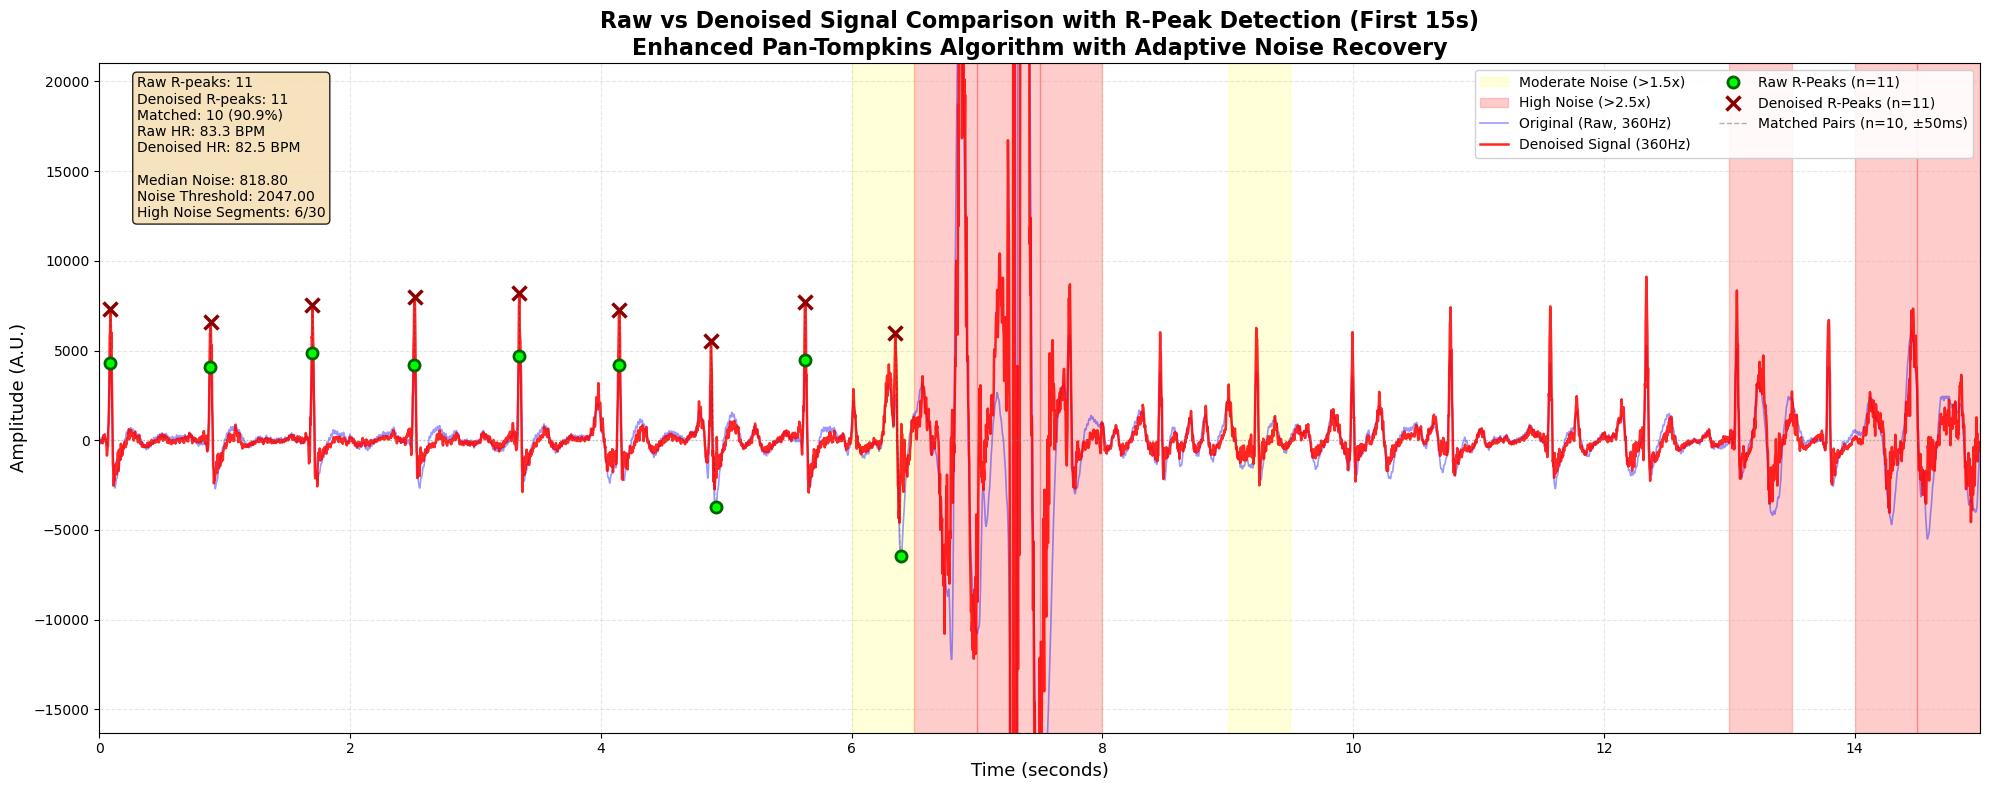


R-PEAK DETECTION COMPARISON (First 15s)
  Raw signal R-peaks detected:        11
  Denoised signal R-peaks detected:   11
  Matched pairs (±50ms):              10 ( 90.9%)
  Difference:                         +0
  Unmatched raw peaks:                 1 (potential false negatives)
  Unmatched denoised peaks:            1 (potential false positives)

  Raw Heart Rate:                     83.3 BPM
  Denoised Heart Rate:                82.5 BPM
  HR Difference:                      -0.7 BPM ( -0.9%)

  Raw RR-RMSSD:                      102.0 ms
  Denoised RR-RMSSD:                  74.1 ms
  RMSSD Reduction:                   +27.9 ms (+27.4%)

  Noise Analysis------------------------------------------------------
  Total segments analyzed:            30 (0.5s each)
  Clean segments:                     22
  Moderate noise segments:             2
  High noise segments:                 6
  Median noise level:                 818.80
  Max noise level:                   9726.79
  Noise thr

In [128]:
# === 11. Diagnostic Visualization: Raw vs Denoised with R-Peaks ===

def visualize_rpeak_comparison(raw_sig, deno_sig, rpeak_raw, rpeak_deno, fs, seconds_to_show=10):
    """
    원본 및 디노이징된 신호를 오버레이하고 검출된 R-peak을 마커로 표시합니다.
    노이즈 구간도 함께 표시하여 알고리즘의 강건성을 시각적으로 확인합니다.
    """
    total_samples = len(raw_sig)
    samples_to_show = int(fs * seconds_to_show)
    samples_to_show = min(total_samples, samples_to_show)
    
    time_sec = np.linspace(0, (total_samples - 1) / fs, total_samples)[:samples_to_show]
    
    # 시각화할 샘플 범위 내의 R-peak만 필터링
    rpeak_raw_plot = rpeak_raw[(rpeak_raw < samples_to_show)]
    rpeak_deno_plot = rpeak_deno[(rpeak_deno < samples_to_show)]
    
    # 노이즈 레벨 계산 (0.5초 구간별 - 더 세밀하게)
    segment_duration = int(0.5 * fs)  # 0.5초
    num_segments = samples_to_show // segment_duration
    noise_segments = []
    
    for seg_idx in range(num_segments):
        seg_start = seg_idx * segment_duration
        seg_end = min(seg_start + segment_duration, samples_to_show)
        seg_raw = raw_sig[seg_start:seg_end]
        
        # MAD 기반 노이즈 추정
        median_val = np.median(seg_raw)
        mad = np.median(np.abs(seg_raw - median_val))
        noise_level = mad * 1.4826
        
        noise_segments.append({
            'start': seg_start / fs,
            'end': seg_end / fs,
            'noise_level': noise_level
        })
    
    # 노이즈 임계값 (중앙값의 2.5배)
    noise_levels_list = [ns['noise_level'] for ns in noise_segments]
    median_noise = np.median(noise_levels_list)
    noise_threshold = median_noise * 2.5
    
    # y축 범위 계산 (백분위수 기반으로 극단값 제외)
    raw_segment = raw_sig[:samples_to_show]
    deno_segment = deno_sig[:samples_to_show]
    
    # 1st와 99th 백분위수 계산 (노이즈 극단값 제외)
    all_values = np.concatenate([raw_segment, deno_segment])
    y_min, y_max = np.percentile(all_values, [1, 99])
    
    # 15% 마진 추가
    y_margin = (y_max - y_min) * 0.15
    y_limits = [y_min - y_margin, y_max + y_margin]

    plt.figure(figsize=(20, 8))
    
    # 0. 노이즈 구간 배경 표시 (3단계 색상)
    high_noise_shown = False
    moderate_noise_shown = False
    
    for ns in noise_segments:
        if ns['noise_level'] > noise_threshold:
            # 높은 노이즈 (빨간색)
            plt.axvspan(ns['start'], ns['end'], alpha=0.2, color='red', 
                       label='High Noise (>2.5x)' if not high_noise_shown else None)
            high_noise_shown = True
        elif ns['noise_level'] > median_noise * 1.5:
            # 중간 노이즈 (노란색)
            plt.axvspan(ns['start'], ns['end'], alpha=0.15, color='yellow', 
                       label='Moderate Noise (>1.5x)' if not moderate_noise_shown else None)
            moderate_noise_shown = True
    
    # 1. 원본 신호 (옅은 파란색)
    plt.plot(time_sec, raw_sig[:samples_to_show], 'b-', alpha=0.4, 
             label=f'Original (Raw, {fs}Hz)', linewidth=1.2)
    
    # 2. 디노이징 신호 (진한 빨간색)
    plt.plot(time_sec, deno_sig[:samples_to_show], 'r-', alpha=0.85, 
             label=f'Denoised Signal ({fs}Hz)', linewidth=1.8)
    
    # 3. 원본 R-Peak 마커 (녹색 원)
    if len(rpeak_raw_plot) > 0:
        plt.plot(rpeak_raw_plot / fs, raw_sig[rpeak_raw_plot], 'o', 
                 markerfacecolor='lime', markeredgecolor='darkgreen', markersize=8, 
                 markeredgewidth=2, label=f'Raw R-Peaks (n={len(rpeak_raw_plot)})', zorder=5)
    
    # 4. 디노이징 R-Peak 마커 (빨간색 X)
    if len(rpeak_deno_plot) > 0:
        plt.plot(rpeak_deno_plot / fs, deno_sig[rpeak_deno_plot], 'x', 
                 markeredgecolor='darkred', markersize=10, markeredgewidth=2.5, 
                 label=f'Denoised R-Peaks (n={len(rpeak_deno_plot)})', zorder=5)
    
    # 5. R-peak 매칭 연결선 (가까운 피크들)
    matching_threshold_samples = int(0.05 * fs)  # 50ms
    matched_pairs = []
    
    for idx_raw in rpeak_raw_plot:
        if len(rpeak_deno_plot) == 0:
            continue
        distances = np.abs(rpeak_deno_plot - idx_raw)
        closest_idx = np.argmin(distances)
        
        if distances[closest_idx] <= matching_threshold_samples:
            matched_pairs.append((idx_raw, rpeak_deno_plot[closest_idx]))
    
    # 매칭된 피크 연결 (연한 회색 점선)
    for raw_idx, deno_idx in matched_pairs:
        plt.plot([raw_idx / fs, deno_idx / fs], 
                [raw_sig[raw_idx], deno_sig[deno_idx]], 
                'k--', alpha=0.2, linewidth=0.8)
    
    if matched_pairs:
        plt.plot([], [], 'k--', alpha=0.3, linewidth=1.0, 
                label=f'Matched Pairs (n={len(matched_pairs)}, ±50ms)')
    
    # 6. 베이스라인 (0) 표시
    plt.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    # 통계 정보 텍스트 박스 (더 상세하게)
    stats_text = f'Raw R-peaks: {len(rpeak_raw_plot)}\n'
    stats_text += f'Denoised R-peaks: {len(rpeak_deno_plot)}\n'
    stats_text += f'Matched: {len(matched_pairs)} ({len(matched_pairs)/max(len(rpeak_raw_plot),1)*100:.1f}%)\n'
    
    if len(rpeak_raw_plot) > 1:
        raw_hr = 60 * fs / np.mean(np.diff(rpeak_raw_plot))
        stats_text += f'Raw HR: {raw_hr:.1f} BPM\n'
    if len(rpeak_deno_plot) > 1:
        deno_hr = 60 * fs / np.mean(np.diff(rpeak_deno_plot))
        stats_text += f'Denoised HR: {deno_hr:.1f} BPM\n'
    
    stats_text += f'\nMedian Noise: {median_noise:.2f}\n'
    stats_text += f'Noise Threshold: {noise_threshold:.2f}\n'
    
    high_noise_count = sum(1 for ns in noise_segments if ns['noise_level'] > noise_threshold)
    stats_text += f'High Noise Segments: {high_noise_count}/{len(noise_segments)}'
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85))
    
    plt.title(f'Raw vs Denoised Signal Comparison with R-Peak Detection (First {seconds_to_show}s)\n' +
              f'Enhanced Pan-Tompkins Algorithm with Adaptive Noise Recovery', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Time (seconds)', fontsize=13)
    plt.ylabel('Amplitude (A.U.)', fontsize=13)
    plt.ylim(y_limits)
    plt.xlim([0, seconds_to_show])
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9, ncol=2)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # 추가: R-peak 매칭 분석 (더 상세하게)
    print(f"\n{'='*70}")
    print(f"R-PEAK DETECTION COMPARISON (First {seconds_to_show}s)")
    print(f"{'='*70}")
    print(f"  Raw signal R-peaks detected:      {len(rpeak_raw_plot):4d}")
    print(f"  Denoised signal R-peaks detected: {len(rpeak_deno_plot):4d}")
    print(f"  Matched pairs (±50ms):            {len(matched_pairs):4d} ({len(matched_pairs)/max(len(rpeak_raw_plot),1)*100:5.1f}%)")
    print(f"  Difference:                       {len(rpeak_deno_plot) - len(rpeak_raw_plot):+4d}")
    
    # 미매칭 분석
    unmatched_raw = len(rpeak_raw_plot) - len(matched_pairs)
    unmatched_deno = len(rpeak_deno_plot) - len(matched_pairs)
    print(f"  Unmatched raw peaks:              {unmatched_raw:4d} (potential false negatives)")
    print(f"  Unmatched denoised peaks:         {unmatched_deno:4d} (potential false positives)")
    
    if len(rpeak_raw_plot) > 1 and len(rpeak_deno_plot) > 1:
        raw_hr = 60 * fs / np.mean(np.diff(rpeak_raw_plot))
        deno_hr = 60 * fs / np.mean(np.diff(rpeak_deno_plot))
        print(f"\n  Raw Heart Rate:                   {raw_hr:6.1f} BPM")
        print(f"  Denoised Heart Rate:              {deno_hr:6.1f} BPM")
        print(f"  HR Difference:                    {deno_hr - raw_hr:+6.1f} BPM ({(deno_hr - raw_hr)/raw_hr*100:+5.1f}%)")
        
        # RR 간격 변동성 (RMSSD)
        raw_rr_intervals = np.diff(rpeak_raw_plot)
        deno_rr_intervals = np.diff(rpeak_deno_plot)
        
        raw_rmssd = np.sqrt(np.mean(np.diff(raw_rr_intervals)**2)) / fs * 1000
        deno_rmssd = np.sqrt(np.mean(np.diff(deno_rr_intervals)**2)) / fs * 1000
        
        print(f"\n  Raw RR-RMSSD:                     {raw_rmssd:6.1f} ms")
        print(f"  Denoised RR-RMSSD:                {deno_rmssd:6.1f} ms")
        print(f"  RMSSD Reduction:                  {raw_rmssd - deno_rmssd:+6.1f} ms ({(raw_rmssd - deno_rmssd)/raw_rmssd*100:+5.1f}%)")
    
    # 노이즈 구간 통계
    high_noise_count = sum(1 for ns in noise_segments if ns['noise_level'] > noise_threshold)
    moderate_noise_count = sum(1 for ns in noise_segments if median_noise * 1.5 < ns['noise_level'] <= noise_threshold)
    
    print(f"\n{'  Noise Analysis':-<70}")
    print(f"  Total segments analyzed:          {len(noise_segments):4d} (0.5s each)")
    print(f"  Clean segments:                   {len(noise_segments) - high_noise_count - moderate_noise_count:4d}")
    print(f"  Moderate noise segments:          {moderate_noise_count:4d}")
    print(f"  High noise segments:              {high_noise_count:4d}")
    print(f"  Median noise level:               {median_noise:8.2f}")
    print(f"  Max noise level:                  {max(noise_levels_list):8.2f}")
    print(f"  Noise threshold (2.5x median):    {noise_threshold:8.2f}")
    print(f"{'='*70}\n")

# 함수 호출 (코드의 가장 마지막 부분에 추가)
visualize_rpeak_comparison(lead2_360, denoised_360, rpeak_raw, rpeak_deno, fs_tgt, seconds_to_show=15)

In [129]:
# ==============================
# Cell 1: 라이브러리 임포트
# ==============================
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
from scipy.spatial.distance import cdist
from ipywidgets import IntSlider, HBox, Label, Layout, interact
from IPython.display import display
import json
import matplotlib.pyplot as plt

print("라이브러리 임포트 완료")

라이브러리 임포트 완료


In [130]:
# === 11. Post-Denoising Smoothing (Jitter Removal) ===
from scipy.signal import butter, filtfilt

# LPF 파라미터 (50Hz 저역 통과)
nyq_tgt = 0.5 * fs_tgt
cutoff_freq = 50.0
normalized_cutoff = cutoff_freq / nyq_tgt
order = 3

b_lpf, a_lpf = butter(order, normalized_cutoff, btype='low', analog=False)
denoised_360_smooth = filtfilt(b_lpf, a_lpf, denoised_360)  # 원본 유지

print(f"Post-smoothing 완료: {cutoff_freq} Hz LPF (Order {order})")
print("denoised_360_smooth 생성 → R-peak 검출에 사용")

Post-smoothing 완료: 50.0 Hz LPF (Order 3)
denoised_360_smooth 생성 → R-peak 검출에 사용


In [131]:
# === 12. Save All Signals & R-peaks ===
import os
output_dir = "ajou_outputs"
os.makedirs(output_dir, exist_ok=True)

np.save(os.path.join(output_dir, "raw_360Hz.npy"), lead2_360)
np.save(os.path.join(output_dir, "denoised_360Hz.npy"), denoised_360)
np.save(os.path.join(output_dir, "denoised_360Hz_smooth.npy"), denoised_360_smooth)
np.save(os.path.join(output_dir, "denoised_267Hz.npy"), denoised_267)

print(f"신호 저장 완료 → {output_dir}/")
print(" - raw_360Hz.npy")
print(" - denoised_360Hz.npy")
print(" - denoised_360Hz_smooth.npy")
print(" - denoised_267Hz.npy")

신호 저장 완료 → ajou_outputs/
 - raw_360Hz.npy
 - denoised_360Hz.npy
 - denoised_360Hz_smooth.npy
 - denoised_267Hz.npy


In [132]:
# === 13. Robust R-peak Detection (정규화 + 구간별 적응형) ===
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
from scipy.spatial.distance import cdist

def normalize_global(sig):
    sig = sig - np.median(sig)
    scale = np.std(sig)
    if scale == 0: scale = 1
    return sig / scale, scale

lead2_360_norm, _ = normalize_global(lead2_360)
denoised_360_norm, _ = normalize_global(denoised_360_smooth)  # 스무딩된 신호 사용

print("전체 신호 정규화 완료")

def robust_rpeak_detection(sig, fs=360):
    Nyq = fs / 2
    b, a = butter(3, [8/Nyq, 20/Nyq], btype='band')
    filtered = filtfilt(b, a, sig)
    
    diff = np.diff(filtered)
    squared = diff**2
    ma_win = int(0.12 * fs)
    if ma_win % 2 == 0: ma_win += 1
    ma = np.convolve(squared, np.ones(ma_win)/ma_win, mode='same')
    
    peaks = []
    win_sec = 10
    win_samples = int(win_sec * fs)
    for start in range(0, len(ma), win_samples//2):
        end = min(start + win_samples, len(ma))
        seg = ma[start:end]
        if len(seg) < 100: continue
        thr = np.percentile(seg, 90) * 0.7
        local_peaks, _ = find_peaks(seg, height=thr, distance=int(0.3*fs))
        peaks.extend(local_peaks + start)
    
    peaks = np.array(peaks, dtype=int)
    
    if len(peaks) > 2:
        rr = np.diff(peaks)
        median_rr = np.median(rr)
        valid = [True] * len(peaks)
        for i in range(1, len(peaks)):
            if abs(peaks[i] - peaks[i-1] - median_rr) > 0.6 * median_rr:
                valid[i] = False
        peaks = peaks[valid]
    
    return peaks

rpeak_raw_final = robust_rpeak_detection(lead2_360_norm, fs_tgt)
rpeak_deno_final = robust_rpeak_detection(denoised_360_norm, fs_tgt)

print(f"강건한 R-peak 검출 완료")
print(f" Raw     : {len(rpeak_raw_final)} peaks → HR: {60*fs_tgt/np.mean(np.diff(rpeak_raw_final)):.1f} BPM")
print(f" Denoised: {len(rpeak_deno_final)} peaks → HR: {60*fs_tgt/np.mean(np.diff(rpeak_deno_final)):.1f} BPM")

# R-peak 저장
np.save(os.path.join(output_dir, "rpeak_raw_final.npy"), rpeak_raw_final)
np.save(os.path.join(output_dir, "rpeak_deno_final.npy"), rpeak_deno_final)
np.save(os.path.join(output_dir, "ecg_norm.npy"), lead2_360_norm)
np.save(os.path.join(output_dir, "deno_norm.npy"), denoised_360_norm)

전체 신호 정규화 완료


강건한 R-peak 검출 완료
 Raw     : 1680 peaks → HR: 124.1 BPM
 Denoised: 1615 peaks → HR: 119.3 BPM


In [133]:
# === 14. Final F1 Score (Raw vs Denoised) ===
D = cdist(rpeak_raw_final.reshape(-1,1), rpeak_deno_final.reshape(-1,1))
matches = np.sum(D.min(axis=1) <= int(0.15 * fs_tgt))  # ±150ms

tp = matches
fp = len(rpeak_deno_final) - tp
fn = len(rpeak_raw_final) - tp
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0

print(f"\n최종 성능 평가 (±150ms)")
print(f" TP: {tp}, FP: {fp}, FN: {fn}")
print(f" Precision: {precision:.3f}, Recall: {recall:.3f}")
print(f" F1 Score: {f1:.3f}")


최종 성능 평가 (±150ms)
 TP: 1446, FP: 169, FN: 234
 Precision: 0.895, Recall: 0.861
 F1 Score: 0.878

 TP: 1446, FP: 169, FN: 234
 Precision: 0.895, Recall: 0.861
 F1 Score: 0.878


In [134]:
# === 15. Interactive Final R-peak Visualization ===
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import IntSlider, HBox, Label, Layout
from IPython.display import display
import numpy as np

def plot_final_interactive(start_sec):
    window_sec = 10
    fs = fs_tgt
    start_idx = int(start_sec * fs)
    end_idx = min(start_idx + int(window_sec * fs), len(lead2_360_norm))
    
    t = np.arange(start_idx, end_idx) / fs
    raw_seg = lead2_360_norm[start_idx:end_idx]
    deno_seg = denoised_360_norm[start_idx:end_idx]
    
    pk_raw = rpeak_raw_final[(rpeak_raw_final >= start_idx) & (rpeak_raw_final < end_idx)]
    pk_deno = rpeak_deno_final[(rpeak_deno_final >= start_idx) & (rpeak_deno_final < end_idx)]
    
    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.1,
        subplot_titles=[
            f'Raw ECG – R-peaks: {len(pk_raw)}',
            f'Denoised ECG – R-peaks: {len(pk_deno)} (Post-smoothed)'
        ]
    )
    
    fig.add_trace(go.Scatter(x=t, y=raw_seg, mode='lines', line=dict(color='steelblue'), name='Raw'), row=1, col=1)
    if len(pk_raw) > 0:
        fig.add_trace(go.Scatter(x=pk_raw/fs, y=lead2_360_norm[pk_raw], mode='markers',
                                 marker=dict(color='red', size=10, symbol='star'), name='Raw R'), row=1, col=1)
    
    fig.add_trace(go.Scatter(x=t, y=deno_seg, mode='lines', line=dict(color='green'), name='Denoised'), row=2, col=1)
    if len(pk_deno) > 0:
        fig.add_trace(go.Scatter(x=pk_deno/fs, y=denoised_360_norm[pk_deno], mode='markers',
                                 marker=dict(color='gold', size=10, symbol='star'), name='Deno R'), row=2, col=1)
    
    fig.update_layout(height=650, title=f"R-peak 비교 | {start_sec:.1f}s ~ {start_sec+10:.1f}s")
    fig.update_yaxes(title_text="Amplitude (norm)", row=1, col=1)
    fig.update_xaxes(title_text="Time (s)", row=2, col=1)
    return fig

# 슬라이더 (초 단위)
total_sec = len(lead2_360_norm) / fs_tgt
slider = IntSlider(min=0, max=int(total_sec - 10), step=1, description='Start (s)', 
                   layout=Layout(width='90%'), continuous_update=False)

time_lbl = Label("0.0s ~ 10.0s")
def upd_lbl(v):
    time_lbl.value = f"{v['new']:.1f}s ~ {v['new']+10:.1f}s"
slider.observe(upd_lbl, 'value')

@interact(start_sec=slider)
def show_plot(start_sec):
    return plot_final_interactive(start_sec)

display(HBox([time_lbl], layout=Layout(justify_content='center')))
print(f"인터랙티브 시각화 준비 완료 (총 {total_sec:.1f}초)")

interactive(children=(IntSlider(value=0, continuous_update=False, description='Start (s)', layout=Layout(width…

인터랙티브 시각화 준비 완료 (총 815.8초)
